In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

metrics = pd.read_csv("metrics_sem.csv")
metrics.iloc[0, :]

precision        0.588018
precision_sem    0.000822
recall           0.546901
recall_sem       0.001421
f1               0.495195
f1_sem           0.001170
dice             0.438701
dice_sem         0.000930
Name: 0, dtype: float64

TypeError: only 0-dimensional arrays can be converted to Python scalars

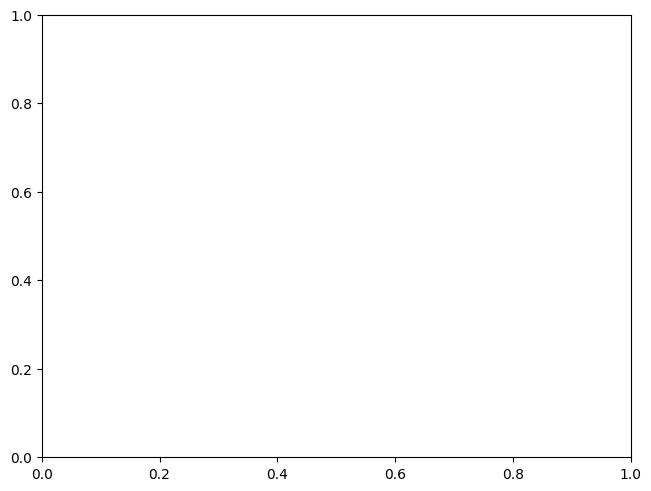

In [ ]:
metric_names = ("Dice", "F1", "Precision", "Recall")
unet_data = metrics.loc[0]
segnet_data = metrics.loc[1]
data = {
    "UNET": (
        (unet_data["dice"], unet_data["f1"], unet_data["precision"], unet_data["recall"]),
        (unet_data["dice_sem"], unet_data["f1_sem"], unet_data["precision_sem"], unet_data["recall_sem"]),
    ),
    "SegNet": (
        (segnet_data["dice"], segnet_data["f1"], segnet_data["precision"], segnet_data["recall"]),
        (segnet_data["dice_sem"], segnet_data["f1_sem"], segnet_data["precision_sem"], segnet_data["recall_sem"]),
    ),
}

x = np.arange(len(metric_names))
width = 0.45
multiplier = 0

fig, ax = plt.subplots(layout="constrained")

for attribute, (measurement, sem) in data.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_title('Comparison of metrics for the SegNet and UNET models')
ax.set_xticks(x + (width/2), metric_names)
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0, 1)